<a href="https://colab.research.google.com/github/Sulu421/BIFX-546_Project-Parkinson-s_Telemonitoring/blob/main/Notebooks/BIFX546_Project__%22Parkinson's_Telemonitoring%22_SulemanMohammad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Project Title: Voice-Based Prediction of Parkinson’s Disease Severity**

##### **Student:       Suleman Mohammad**
##### **School:        Hood Graduate College, MS. Bioinformatics**
##### **Course:        BIFX-546 Machine Learning for Bioinformatics**
##### **Instructor:    Sarangan Ravichandran, Ph.D., PMP**    
##### **Dataset:       Parkinson's Telemonitoring**                                                               

**Disclaimer**: This repository contains analysis of my Final Project for my course  BIFX 546 – Machine Learning for Bioinformatics, focusing on the Parkinsons Telemonitoring dataset. The main goal of this project is to use biomedical voice features to predict clinical motor_UPDRS and total_UPDRS scores for patients with early-stage Parkinson’s disease.

#### =============================================================================
#### 1. DATASET LOADING
#### =============================================================================

##### LOADING THE REQUIRED PACKAGES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### ADDITIONAL PACKAGES WHICH ARE REQUIRED TO LOAD DATASET DIRECTLY FROM THE UCI REPO:

In [2]:
#| echo: false
##To install the ucimlrepo package, you can use the following command in your terminal or command prompt:
%pip install ucimlrepo

##In Jupyter Notebook, you can use the following command to install the ucimlrepo package:
#!pip3 install -U ucimlrepo

from ucimlrepo import fetch_ucirepo

#####  LOADING THE DATASET USING DIFFERENT APPROACHES

**NOTE:** Select and implement the approach that best aligns with your methodology. Comment out any alternative approaches not used in the final implementation.

In [3]:
# 1. Load the dataset from the local CSV file
#df = pd.read_csv('Pakisons-Data-File.csv')

# 2. Load the dataset from the local excel file
#df = pd.read_excel('Pakisons-Data-File.xlsx')

# 3. Load dataset using ucimlrepo package (recommended approach)
parkinsons_telemonitoring = fetch_ucirepo(id=189)

# metadata
print(parkinsons_telemonitoring.metadata)
# variable information
print(parkinsons_telemonitoring.variables)
# Create a working copy of the dataset
df = parkinsons_telemonitoring.data["original"].copy()

# Basic structure
df_shape = df.shape
n_patients = df["subject#"].nunique()
n_records = len(df)
print(f"Dataset shape: {df_shape}")
print(f"Unique patients: {n_patients} | Total recordings: {n_records}")


{'uci_id': 189, 'name': 'Parkinsons Telemonitoring', 'repository_url': 'https://archive.ics.uci.edu/dataset/189/parkinsons+telemonitoring', 'data_url': 'https://archive.ics.uci.edu/static/public/189/data.csv', 'abstract': "Oxford Parkinson's Disease Telemonitoring Dataset", 'area': 'Health and Medicine', 'tasks': ['Regression'], 'characteristics': ['Tabular'], 'num_instances': 5875, 'num_features': 19, 'feature_types': ['Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['motor_UPDRS', 'total_UPDRS'], 'index_col': ['subject#'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5ZS3N', 'creators': ['Athanasios Tsanas', 'Max Little'], 'intro_paper': {'ID': 229, 'type': 'NATIVE', 'title': "Accurate Telemonitoring of Parkinson's Disease Progression by Noninvasive Speech Tests", 'authors': 'A. Tsanas, Max A. Little, P. McSharry, L. Ramig', 'venue': 'IEEE Transactions on Bio

#### =============================================================================
#### 2. INITIAL DATA CLEANING
#### =============================================================================

In [4]:
# Check for missing values
missing_values = df.isnull().sum()

# Check for duplicates
duplicates = df.duplicated().sum()

# Check data types
print(df.dtypes)

# Drop the unnecessary index column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df.columns

subject#           int64
age                int64
sex                int64
test_time        float64
Jitter(%)        float64
Jitter(Abs)      float64
Jitter:RAP       float64
Jitter:PPQ5      float64
Jitter:DDP       float64
Shimmer          float64
Shimmer(dB)      float64
Shimmer:APQ3     float64
Shimmer:APQ5     float64
Shimmer:APQ11    float64
Shimmer:DDA      float64
NHR              float64
HNR              float64
RPDE             float64
DFA              float64
PPE              float64
motor_UPDRS      float64
total_UPDRS      float64
dtype: object


Index(['subject#', 'age', 'sex', 'test_time', 'Jitter(%)', 'Jitter(Abs)',
       'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP', 'Shimmer', 'Shimmer(dB)',
       'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA', 'NHR',
       'HNR', 'RPDE', 'DFA', 'PPE', 'motor_UPDRS', 'total_UPDRS'],
      dtype='object')

#### =============================================================================
#### 3. SUMMARY STATISTICS
#### =============================================================================

In [5]:
# Basic descriptive statistics
summary = df.describe()

# ── Target Variable statistics ────────────────────────────────────────────
motor_stats = {
    "mean":   df["motor_UPDRS"].mean(),
    "median": df["motor_UPDRS"].median(),
    "std":    df["motor_UPDRS"].std(),
    "min":    df["motor_UPDRS"].min(),
    "max":    df["motor_UPDRS"].max()
}

total_stats = {
    "mean":   df["total_UPDRS"].mean(),
    "median": df["total_UPDRS"].median(),
    "std":    df["total_UPDRS"].std(),
    "min":    df["total_UPDRS"].min(),
    "max":    df["total_UPDRS"].max()
}

# ── Demographics ──────────────────────────────────────────────────────────
Age_mean = df["age"].mean()
Age_min  = df["age"].min()
Age_max  = df["age"].max()

# FIX: use plain assignment, NOT set literal {} — the original code stored
# a Python set {number} instead of the integer itself.
Male   = (df['sex'] == 0).sum()
Female = (df['sex'] == 1).sum()

# ── Recording Period ──────────────────────────────────────────────────────
duration_start = df['test_time'].min()
duration_end   = df['test_time'].max()
average_recordings_per_patient = len(df) / df['subject#'].nunique()

# ── Display all summary statistics ───────────────────────────────────────
print("="*60)
print("MOTOR UPDRS SUMMARY")
print("="*60)
for k, v in motor_stats.items():
    print(f"  {k:<8}: {v:.3f}")

print()
print("="*60)
print("TOTAL UPDRS SUMMARY")
print("="*60)
for k, v in total_stats.items():
    print(f"  {k:<8}: {v:.3f}")

print()
print("="*60)
print("DEMOGRAPHICS")
print("="*60)
print(f"  Age   : mean={Age_mean:.1f}  min={Age_min}  max={Age_max}")
print(f"  Male  : {Male} recordings  ({Male/len(df)*100:.1f}%)")
print(f"  Female: {Female} recordings  ({Female/len(df)*100:.1f}%)")

print()
print("="*60)
print("RECORDING PERIOD")
print("="*60)
print(f"  Recording period          : {duration_start:.1f} to {duration_end:.1f} days since recruitment")
print(f"  Avg recordings per patient: {average_recordings_per_patient:.1f}")


MOTOR UPDRS SUMMARY
  mean    : 21.296
  median  : 20.871
  std     : 8.129
  min     : 5.038
  max     : 39.511

TOTAL UPDRS SUMMARY
  mean    : 29.019
  median  : 27.576
  std     : 10.700
  min     : 7.000
  max     : 54.992

DEMOGRAPHICS
  Age   : mean=64.8  min=36  max=85
  Male  : 4008 recordings  (68.2%)
  Female: 1867 recordings  (31.8%)

RECORDING PERIOD
  Recording period          : -4.3 to 215.5 days since recruitment
  Avg recordings per patient: 139.9


#### =============================================================================
#### 4. VISUALIZATIONS
#### =============================================================================

#### NOTE ON TARGET SELECTION AND HEATMAP SCOPE

**Target variables**: This project uses **two targets** — `motor_UPDRS` and `total_UPDRS`.
Because `total_UPDRS` includes `motor_UPDRS` as a major component, the two are highly correlated
(r ≈ 0.95). We treat **`motor_UPDRS` as the primary target** (it more directly reflects the acoustic
biomarkers of dysarthria) and `total_UPDRS` as a secondary target. Models are evaluated separately
for both to assess whether voice features generalise to the broader clinical score.

**Correlation heatmap**: The heatmap below includes **all 16 voice features** plus both targets.
The Jitter and Shimmer sub-families are highly inter-correlated (r > 0.80–0.91), which motivates
the use of Ridge/Lasso regularisation and Random Forest in the modelling phase.


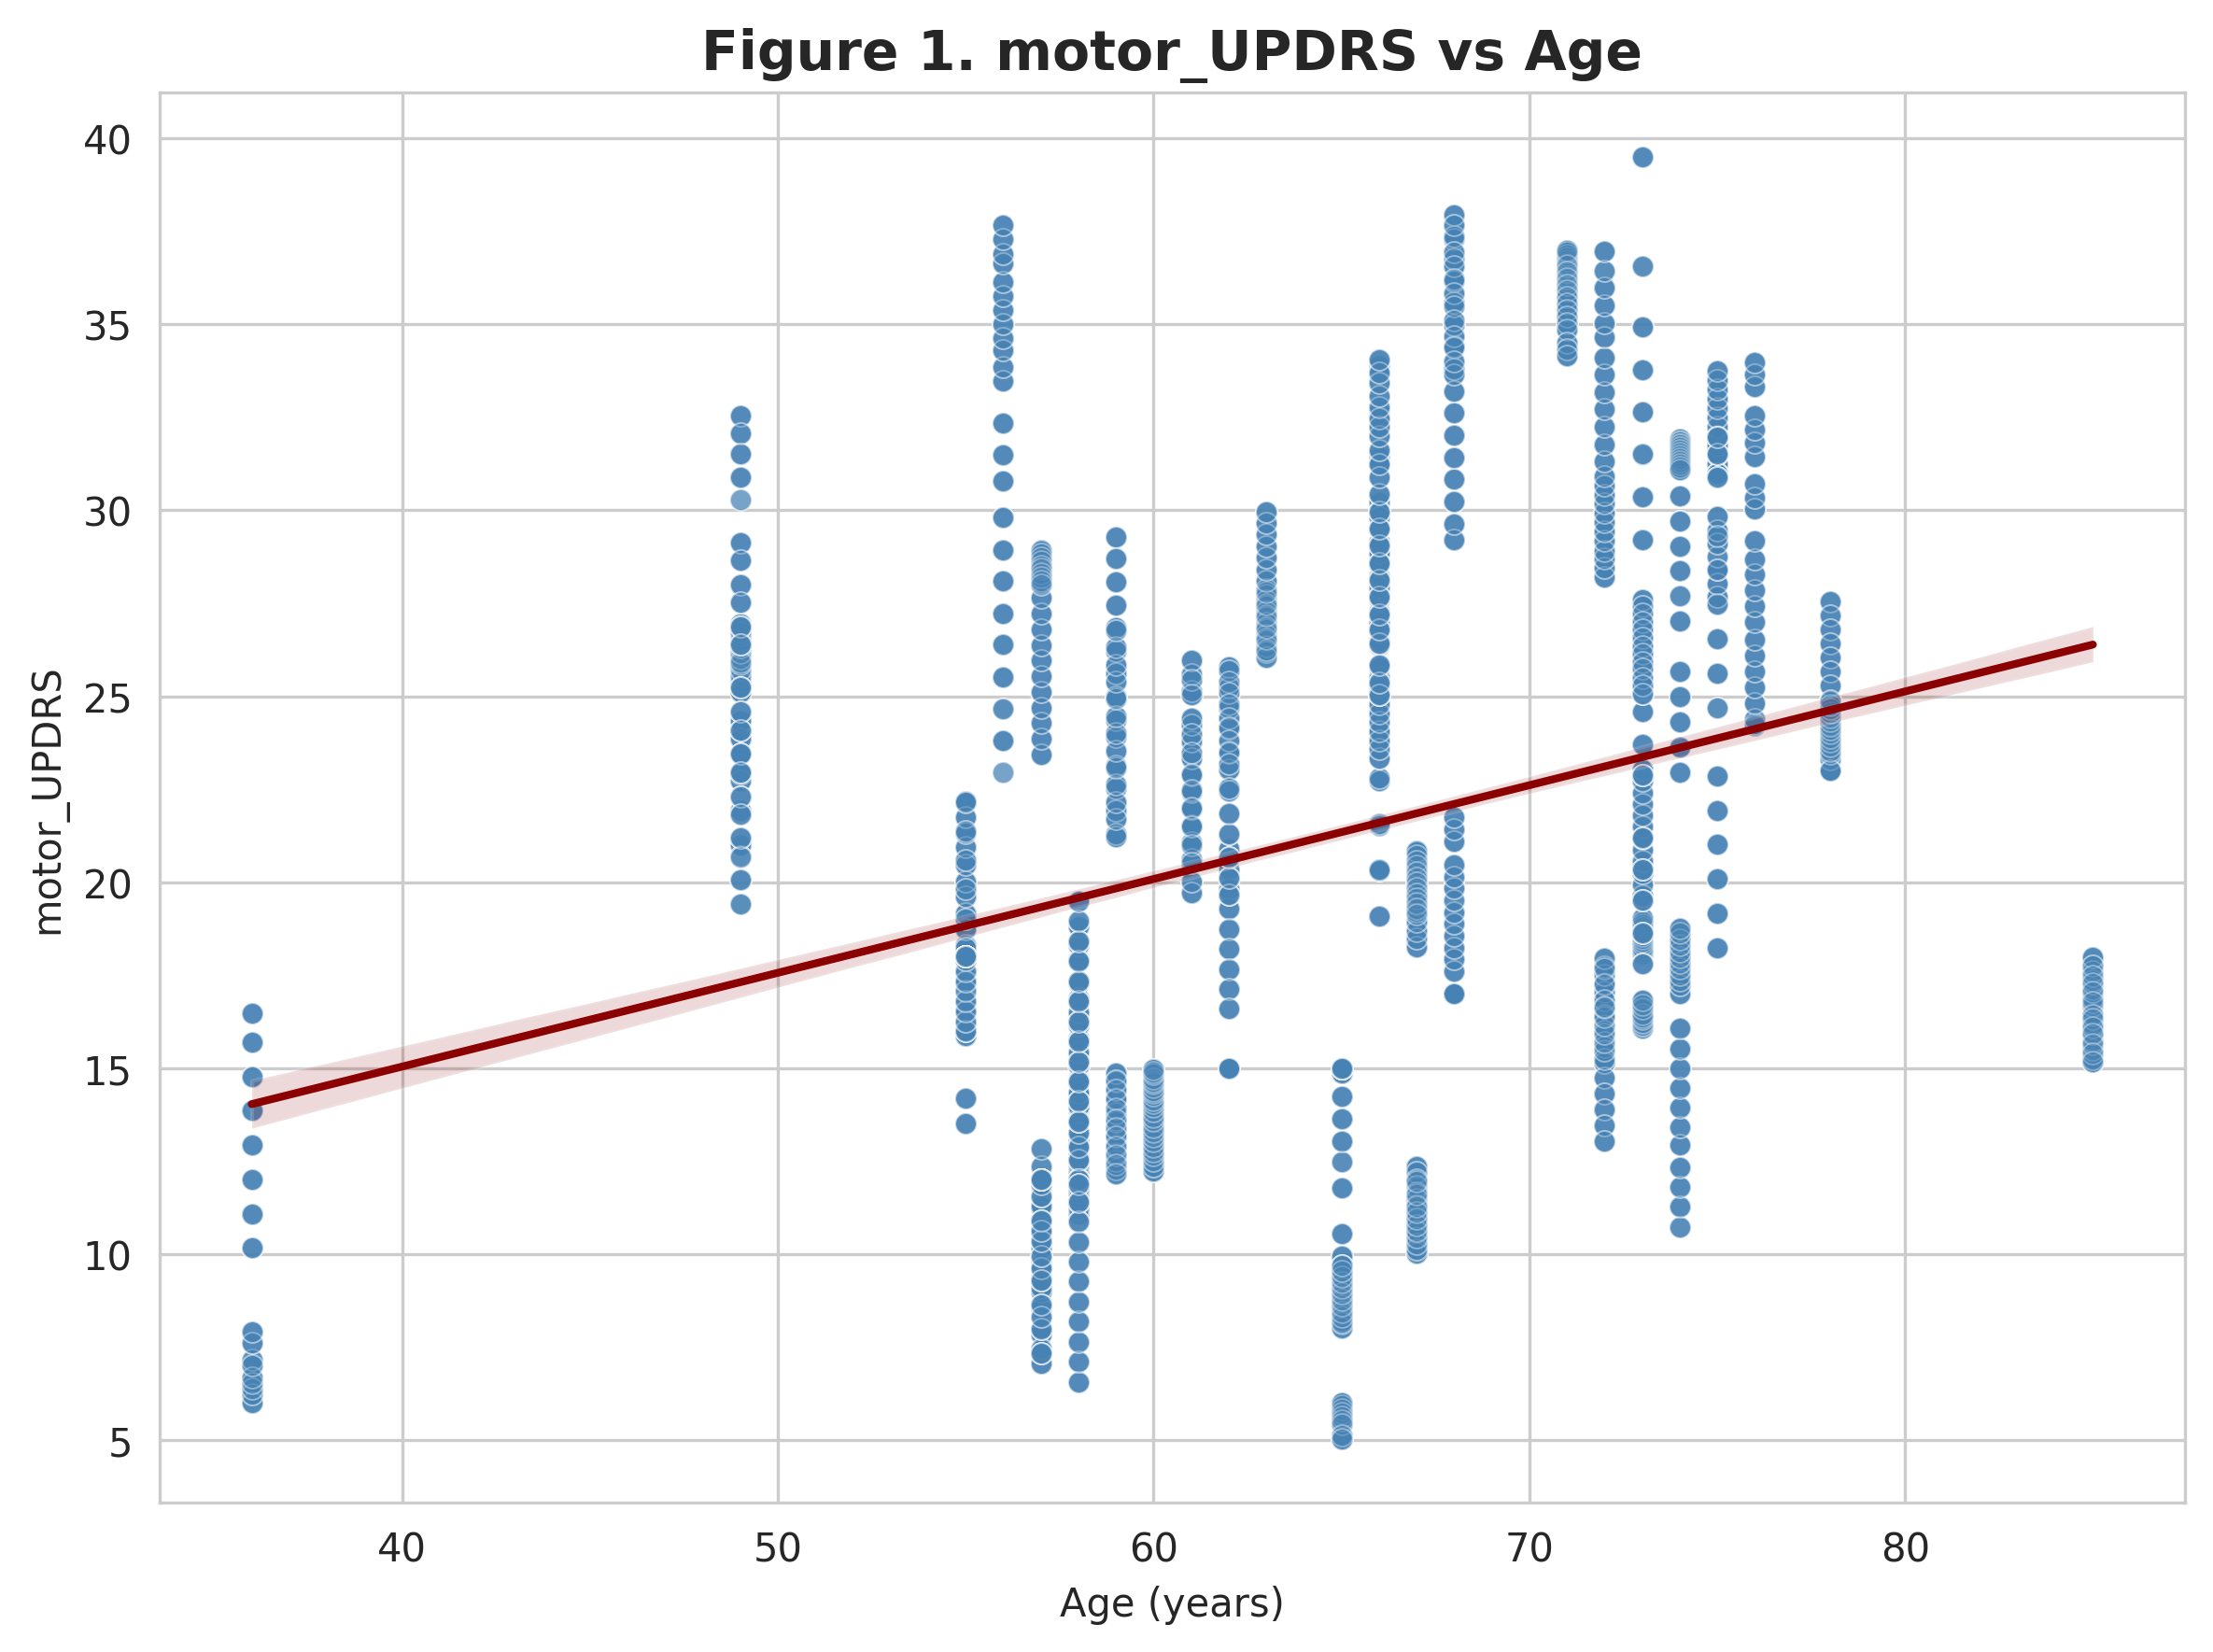

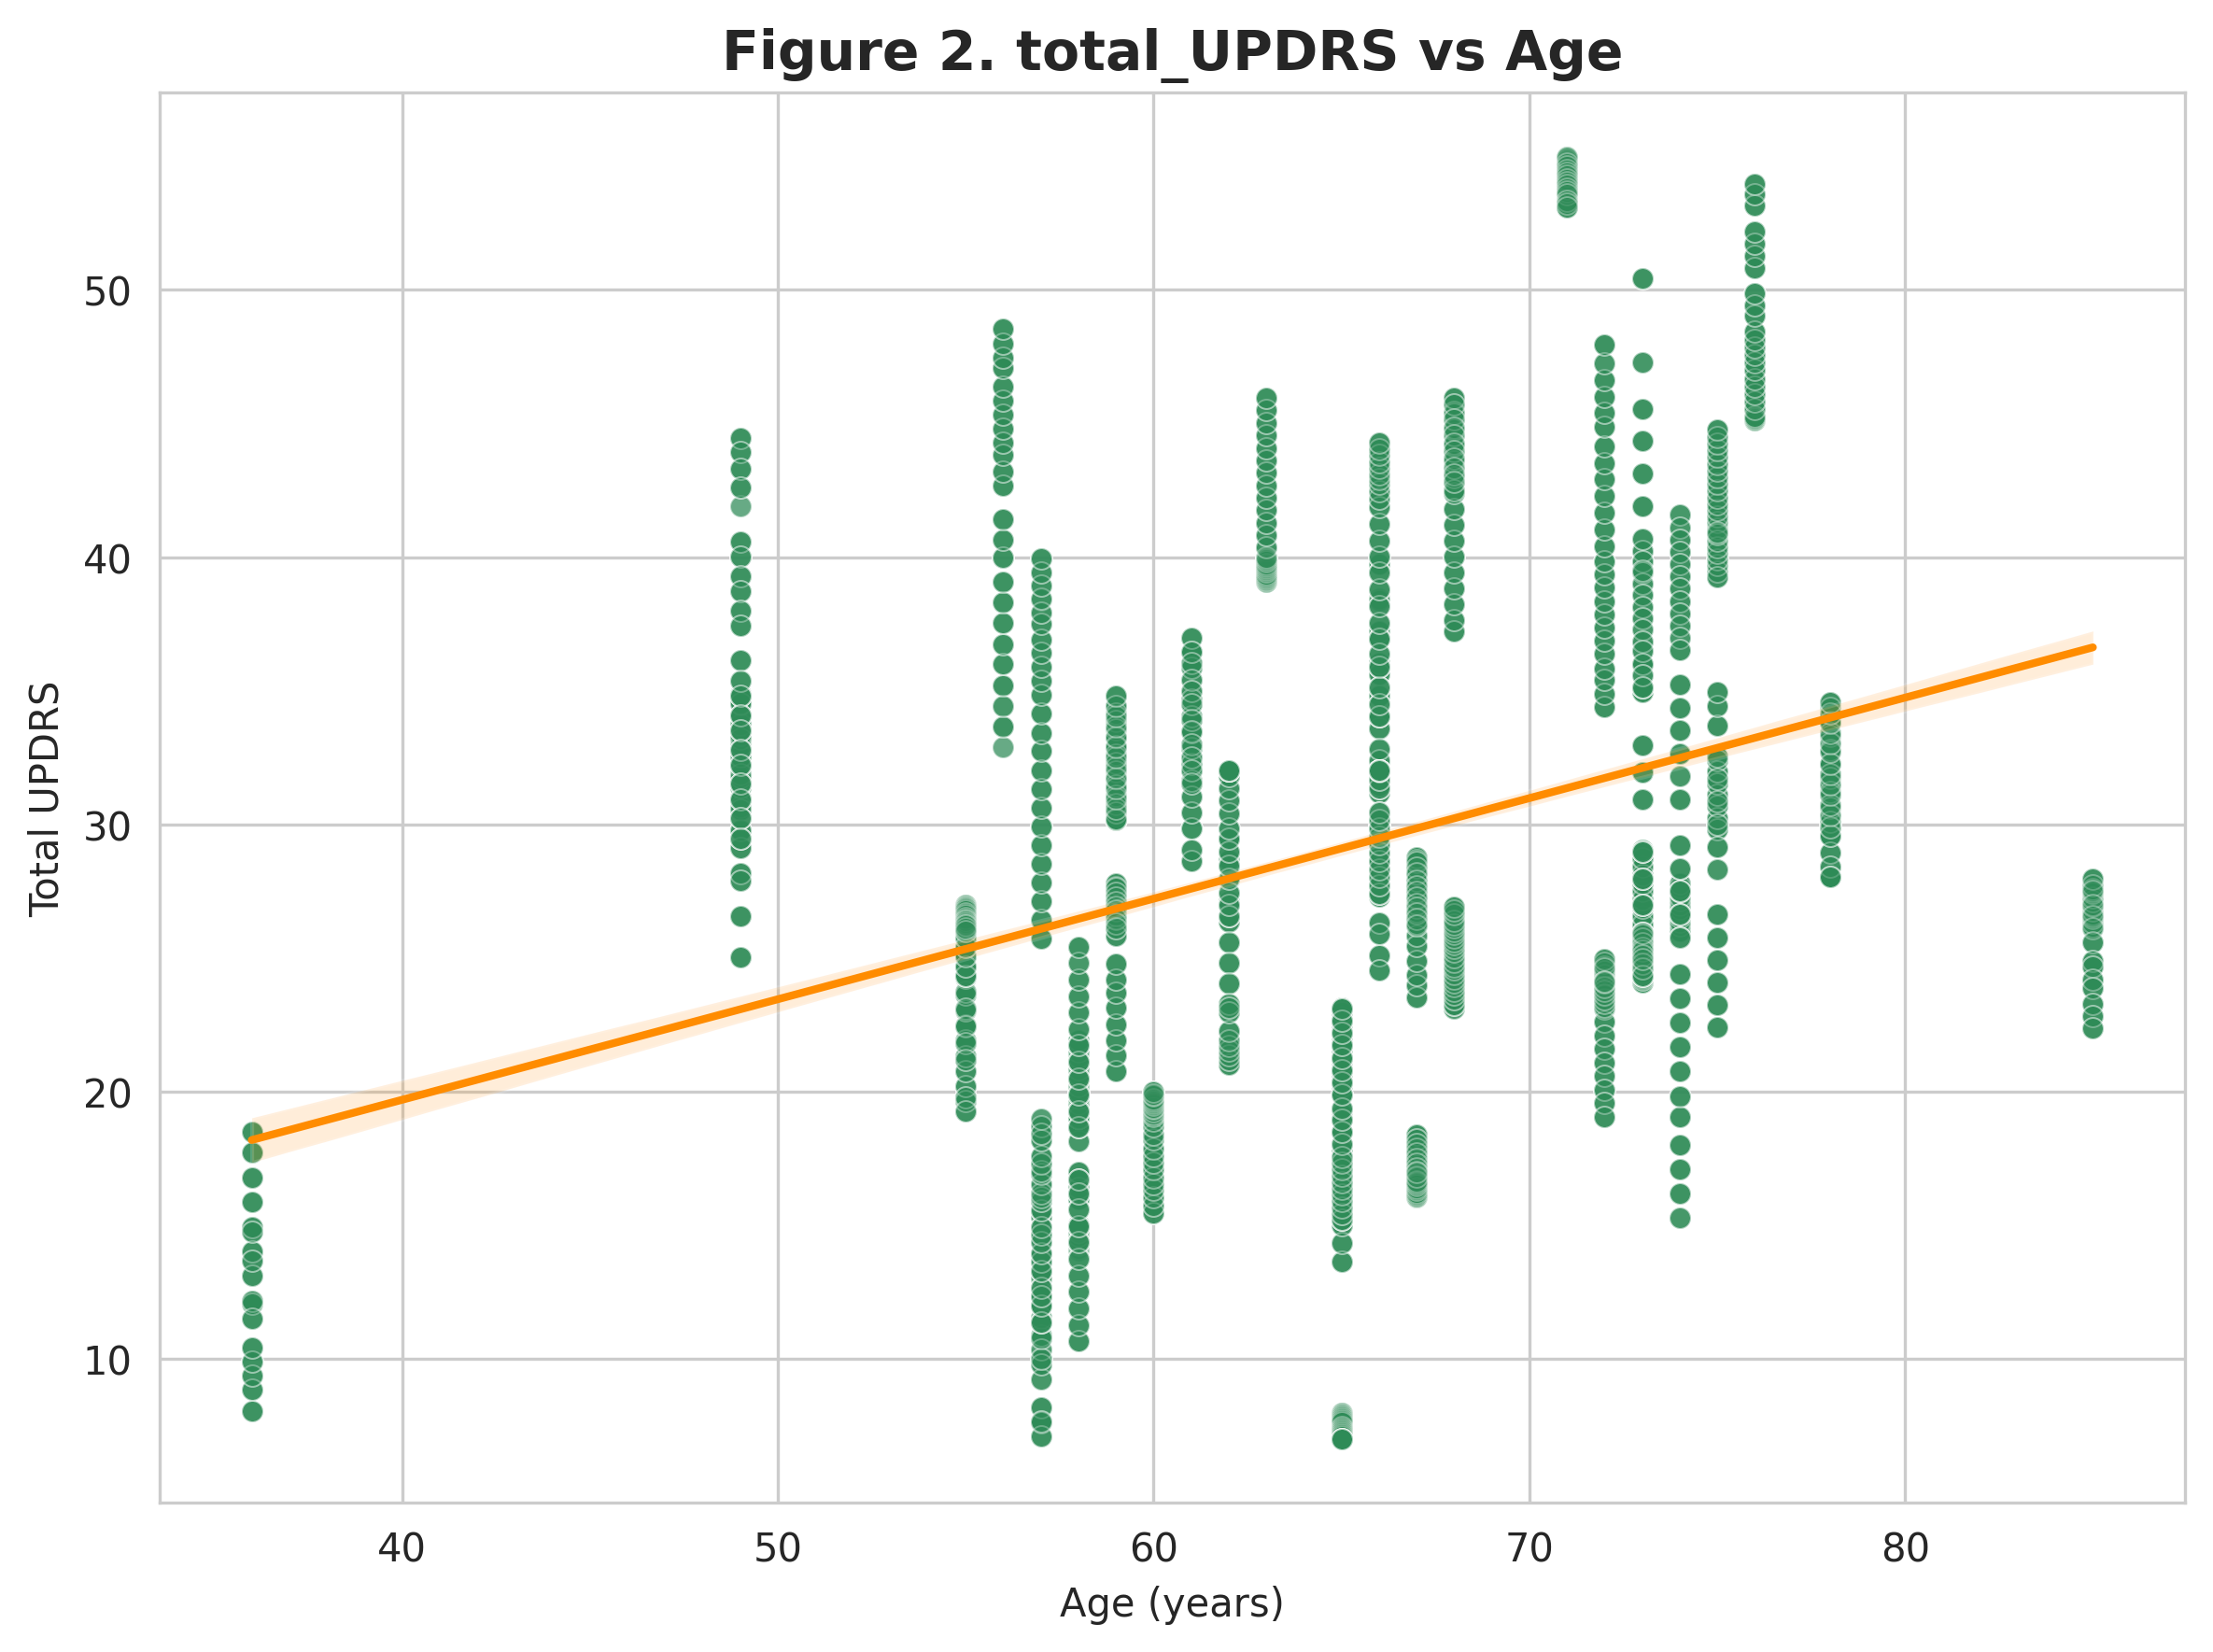

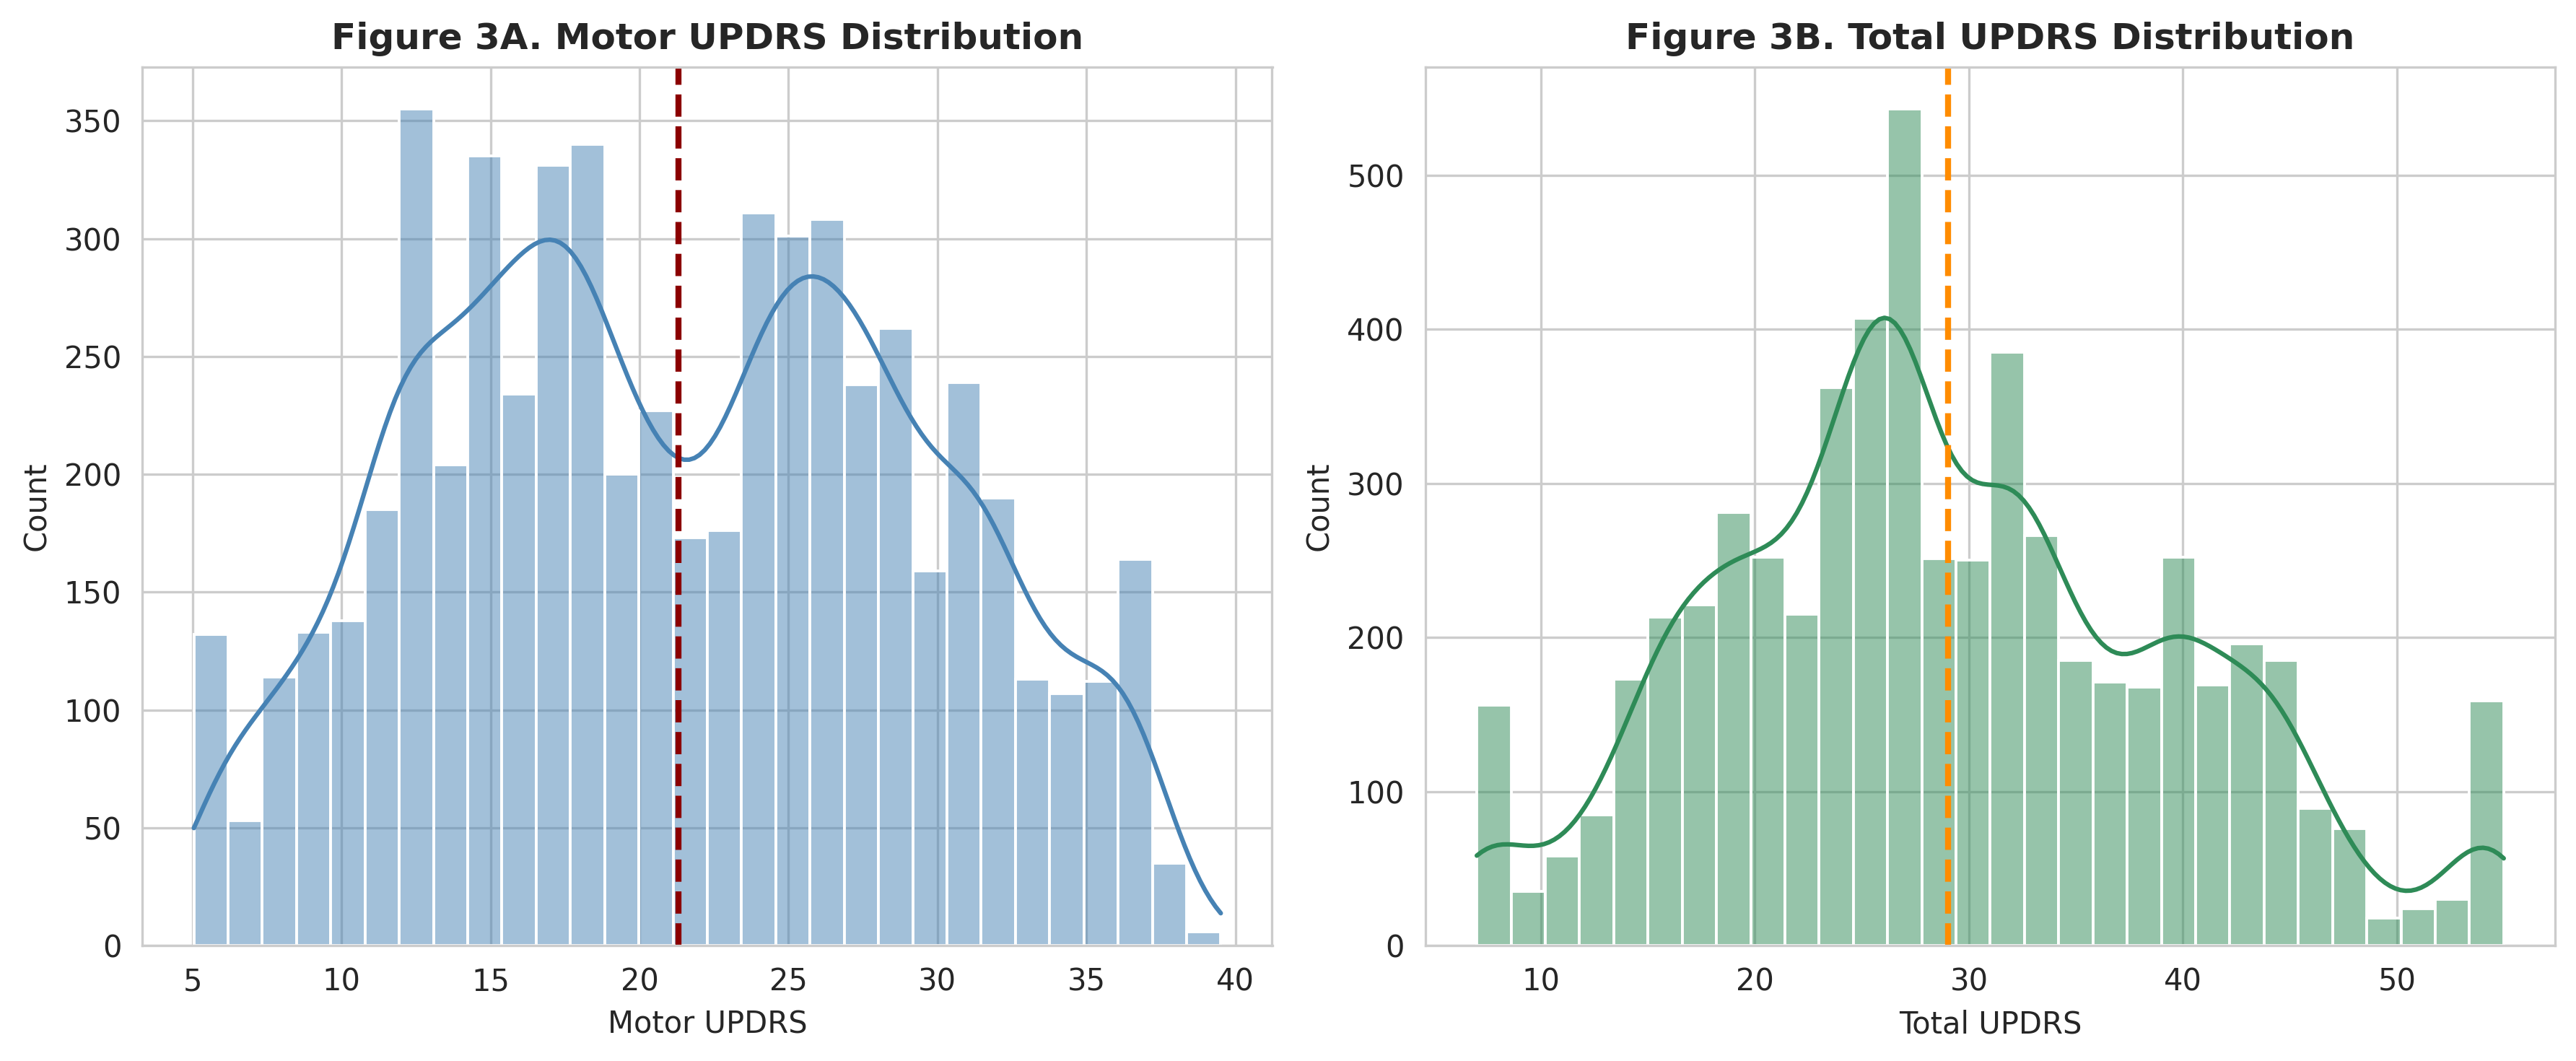

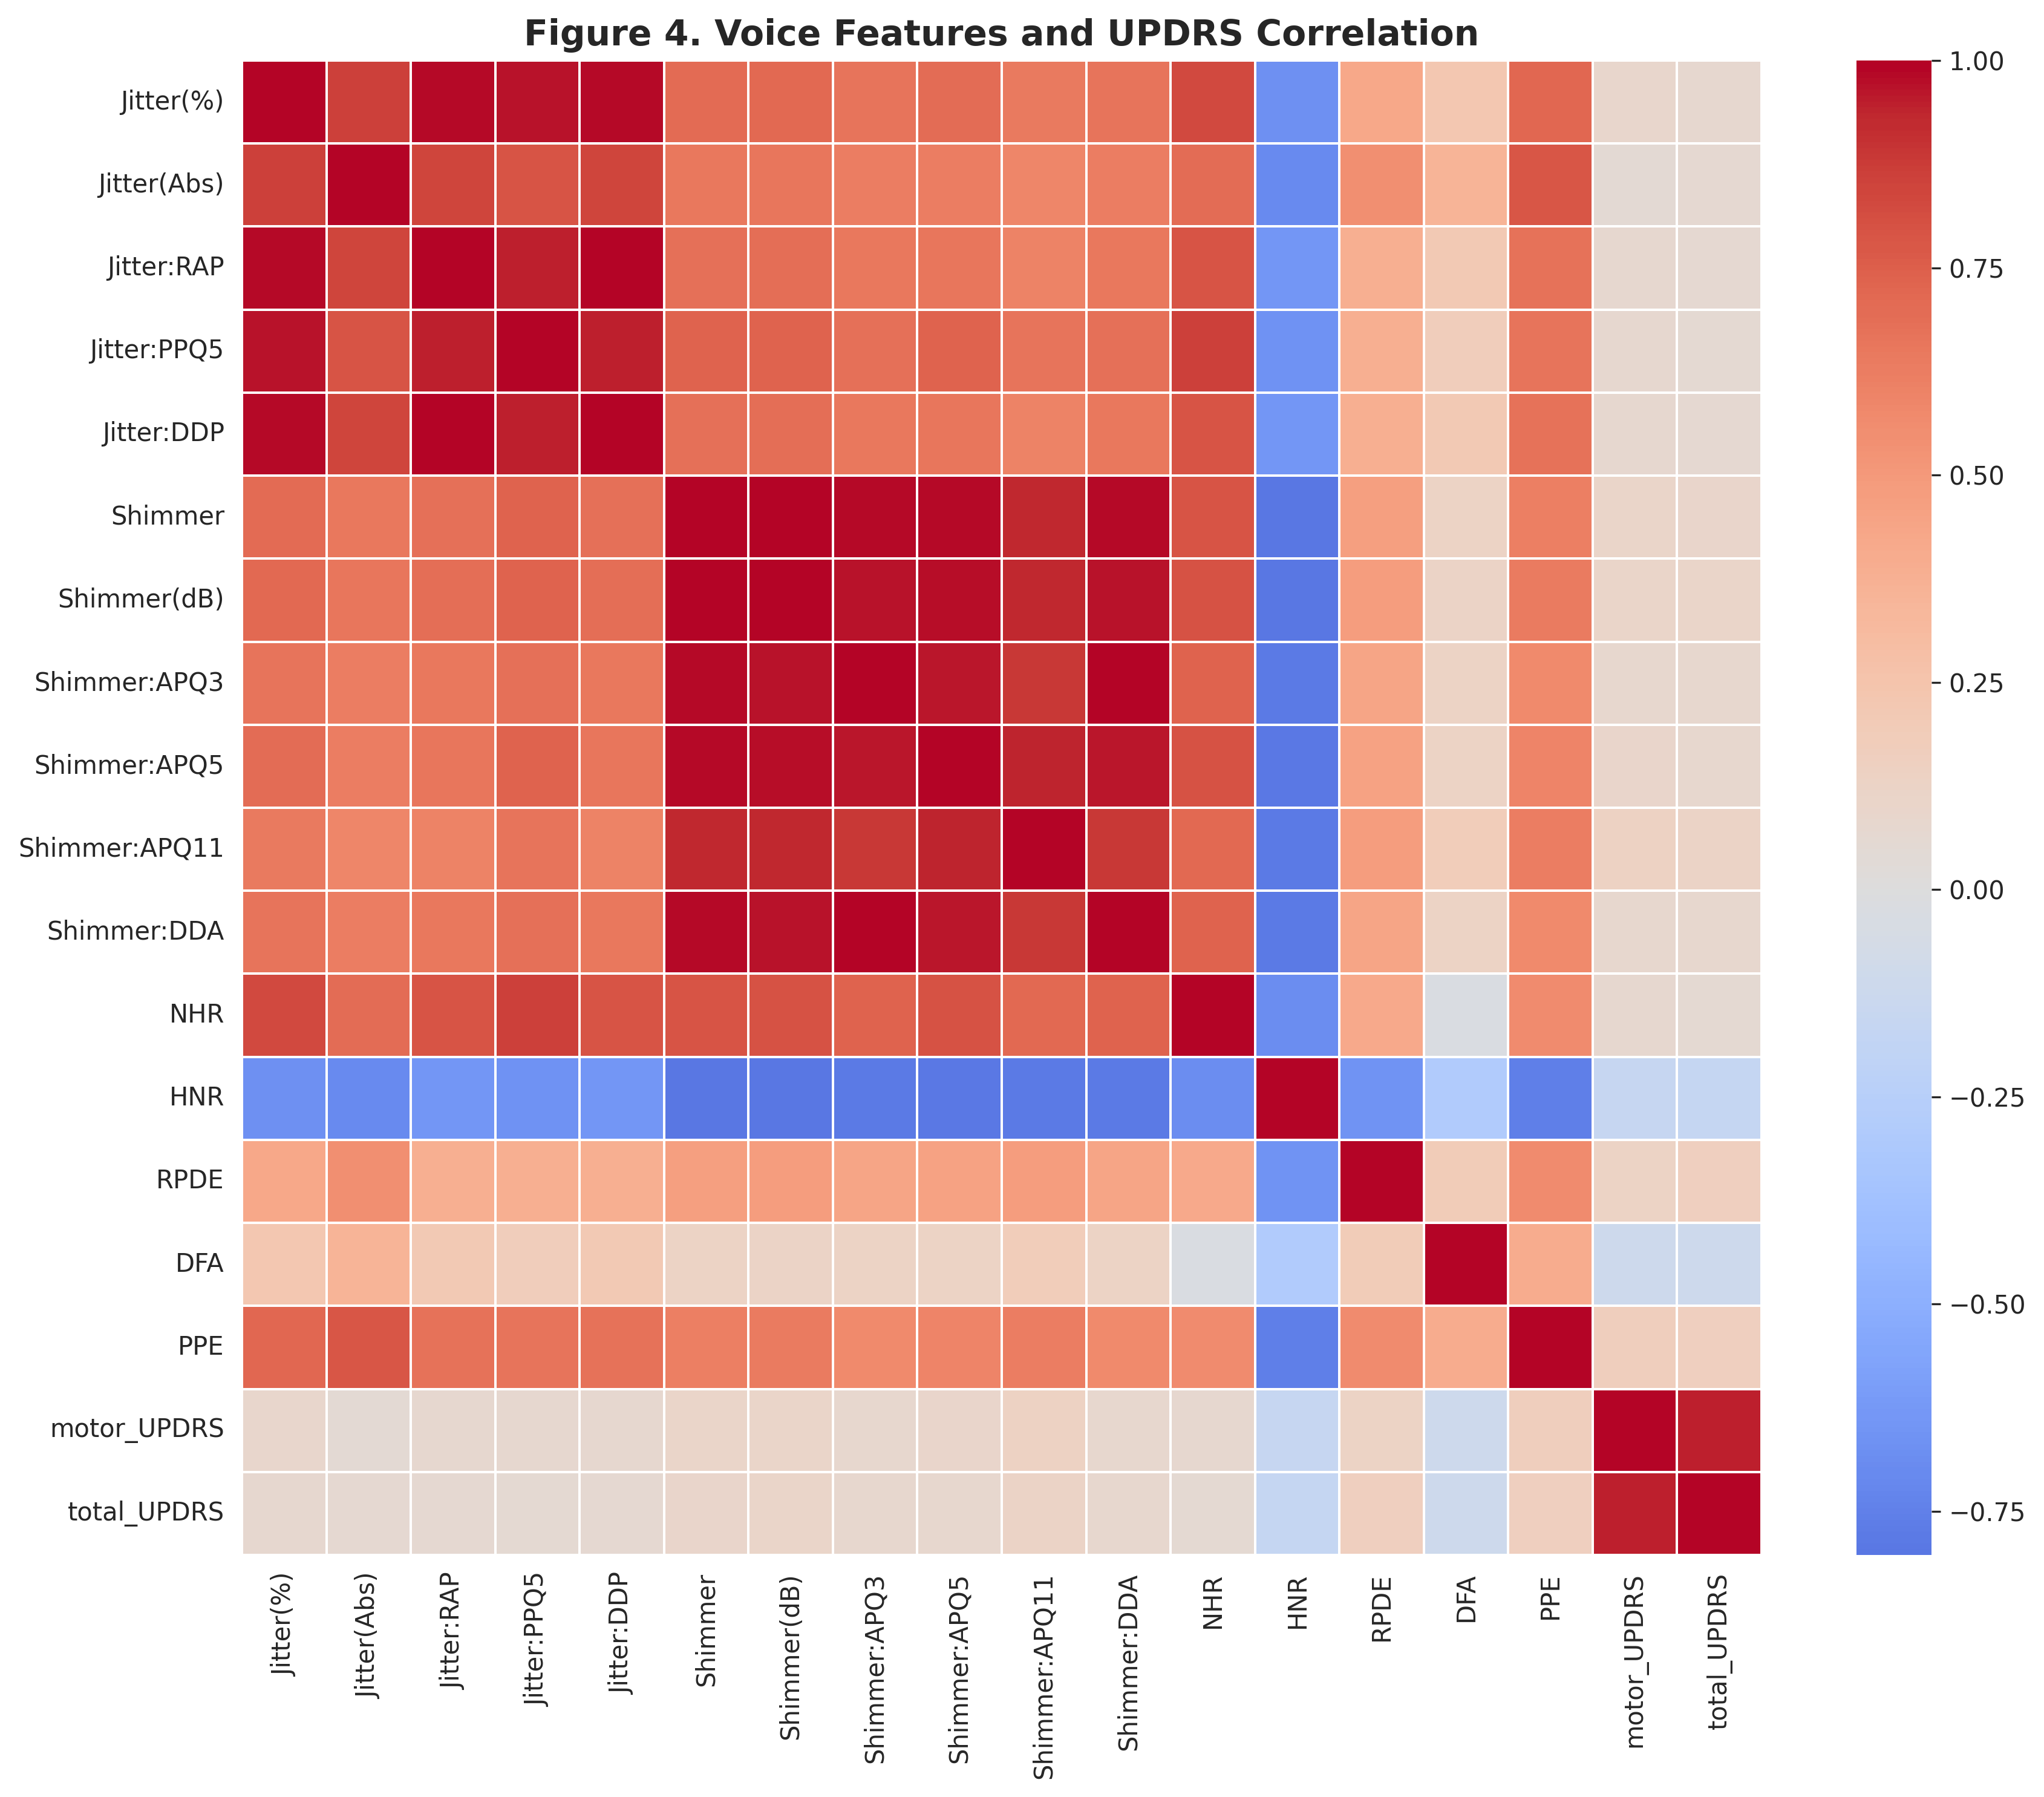

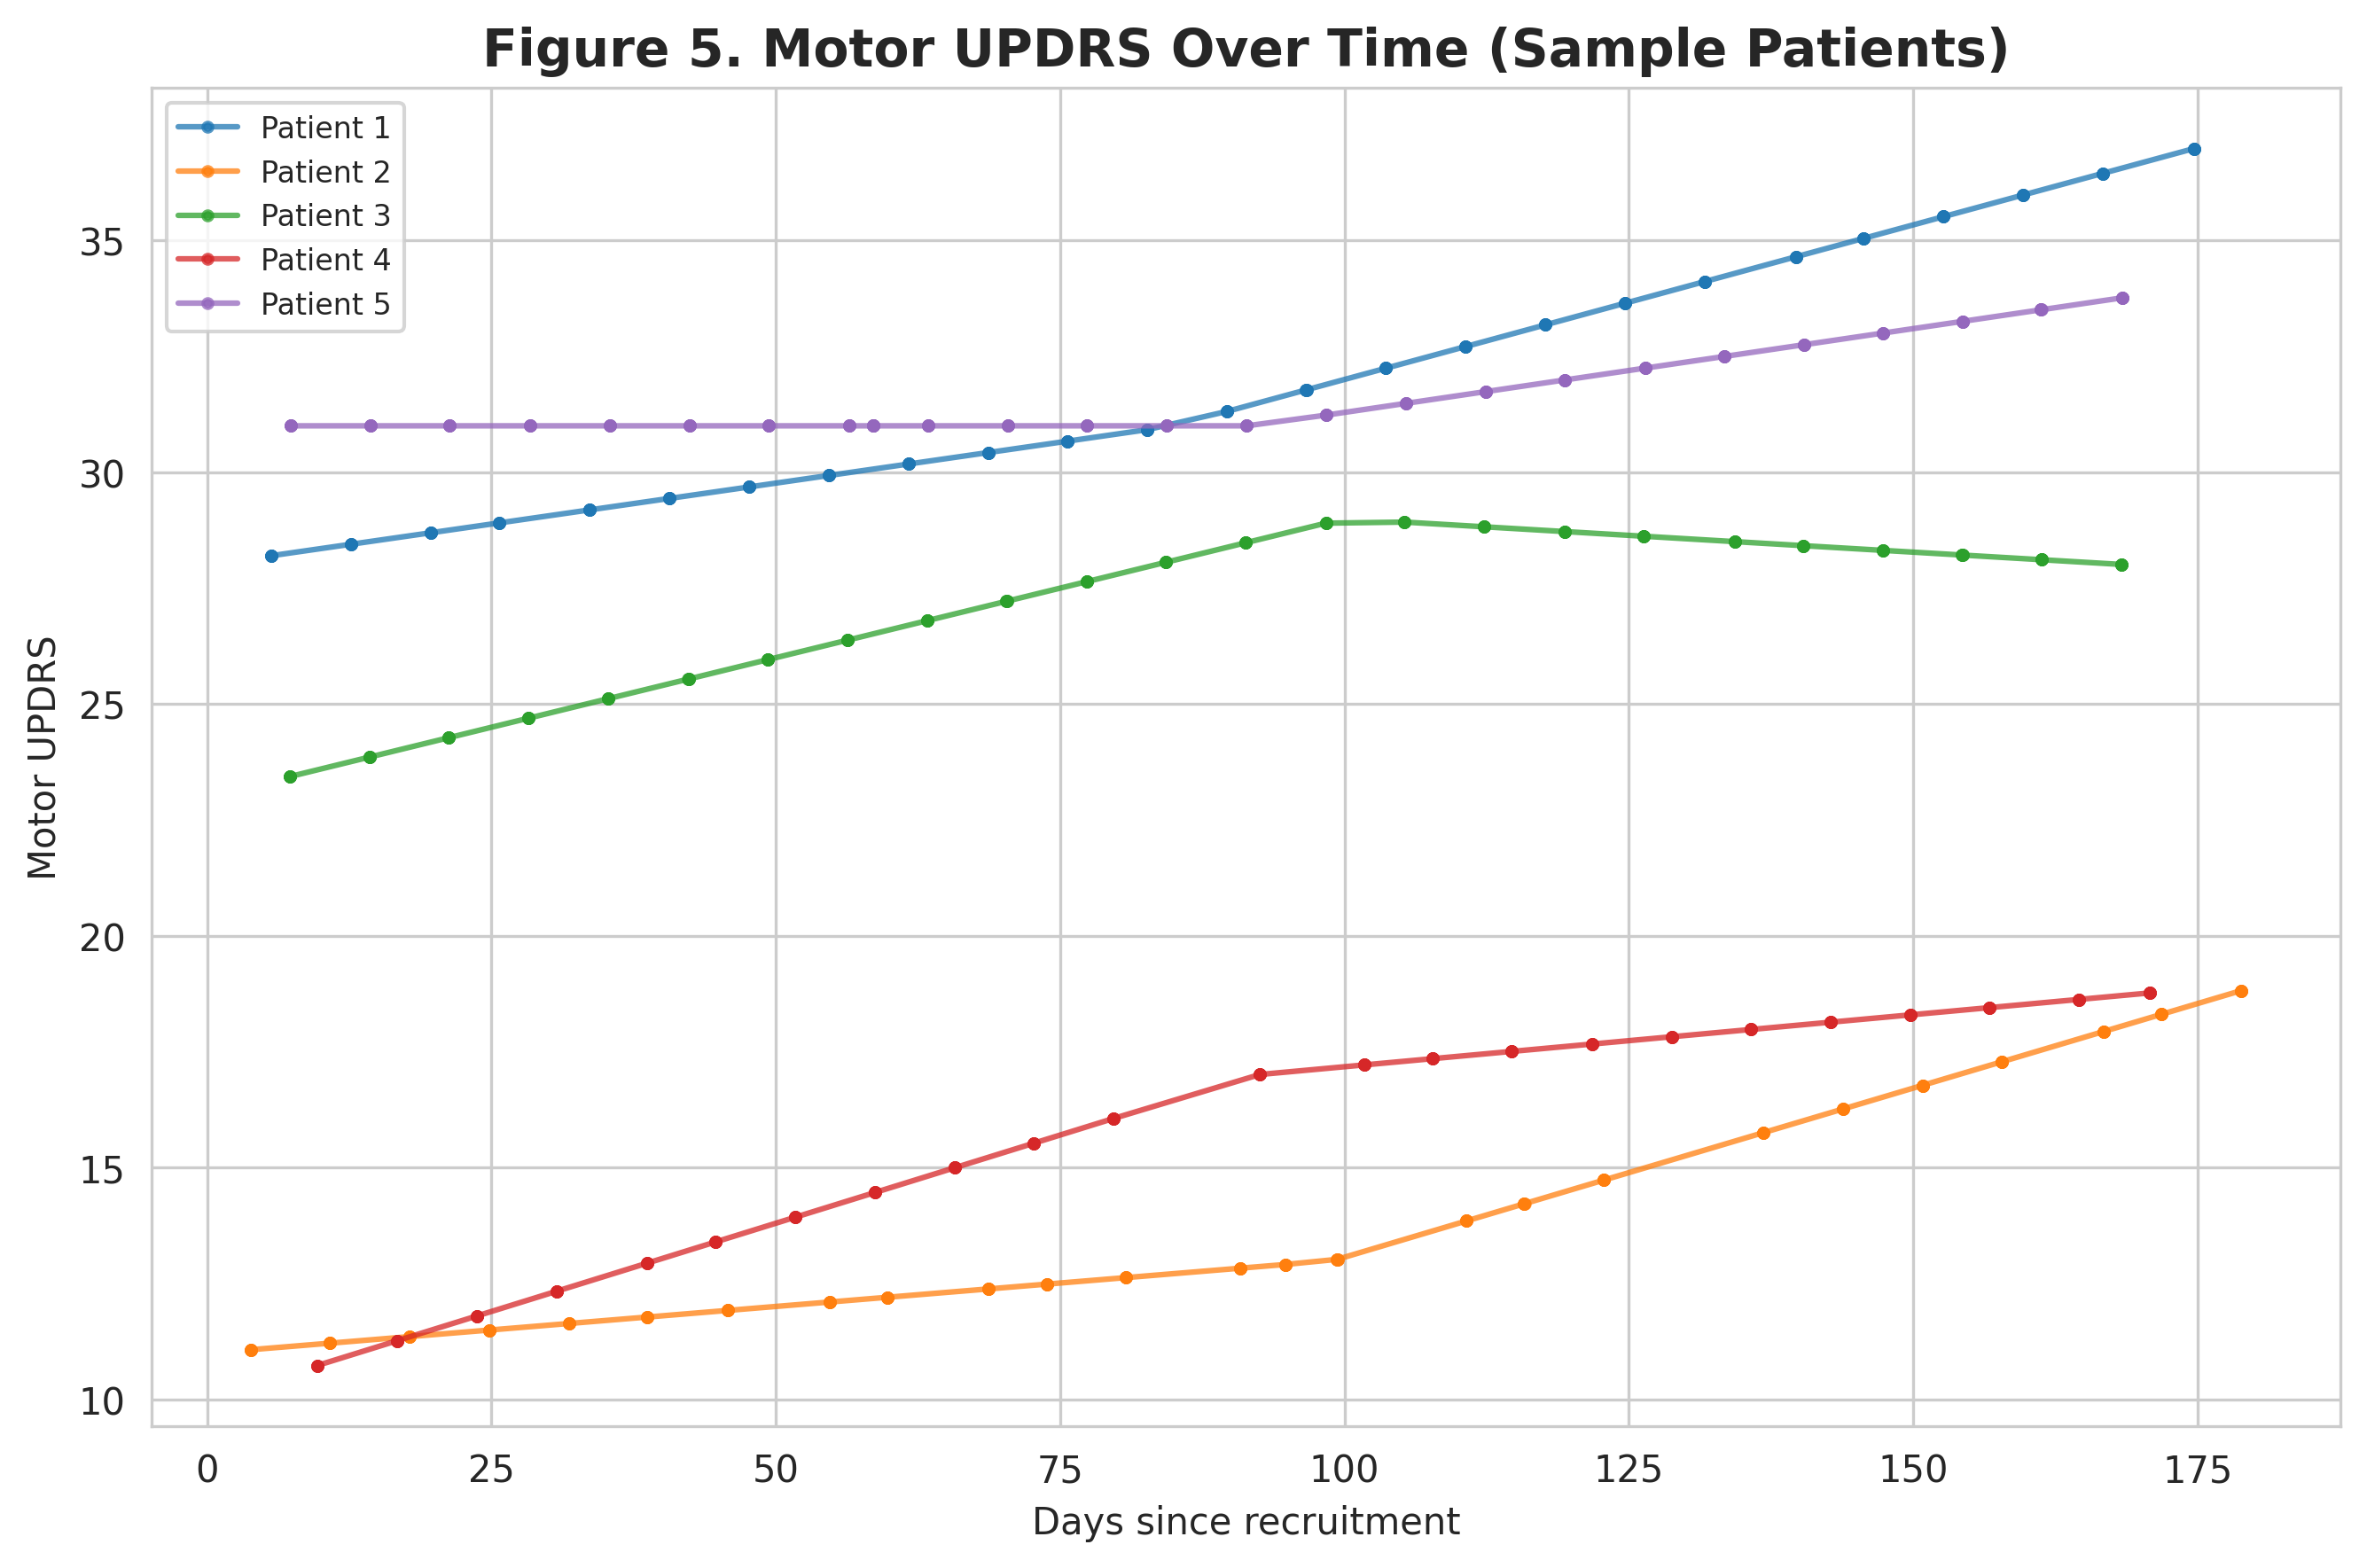

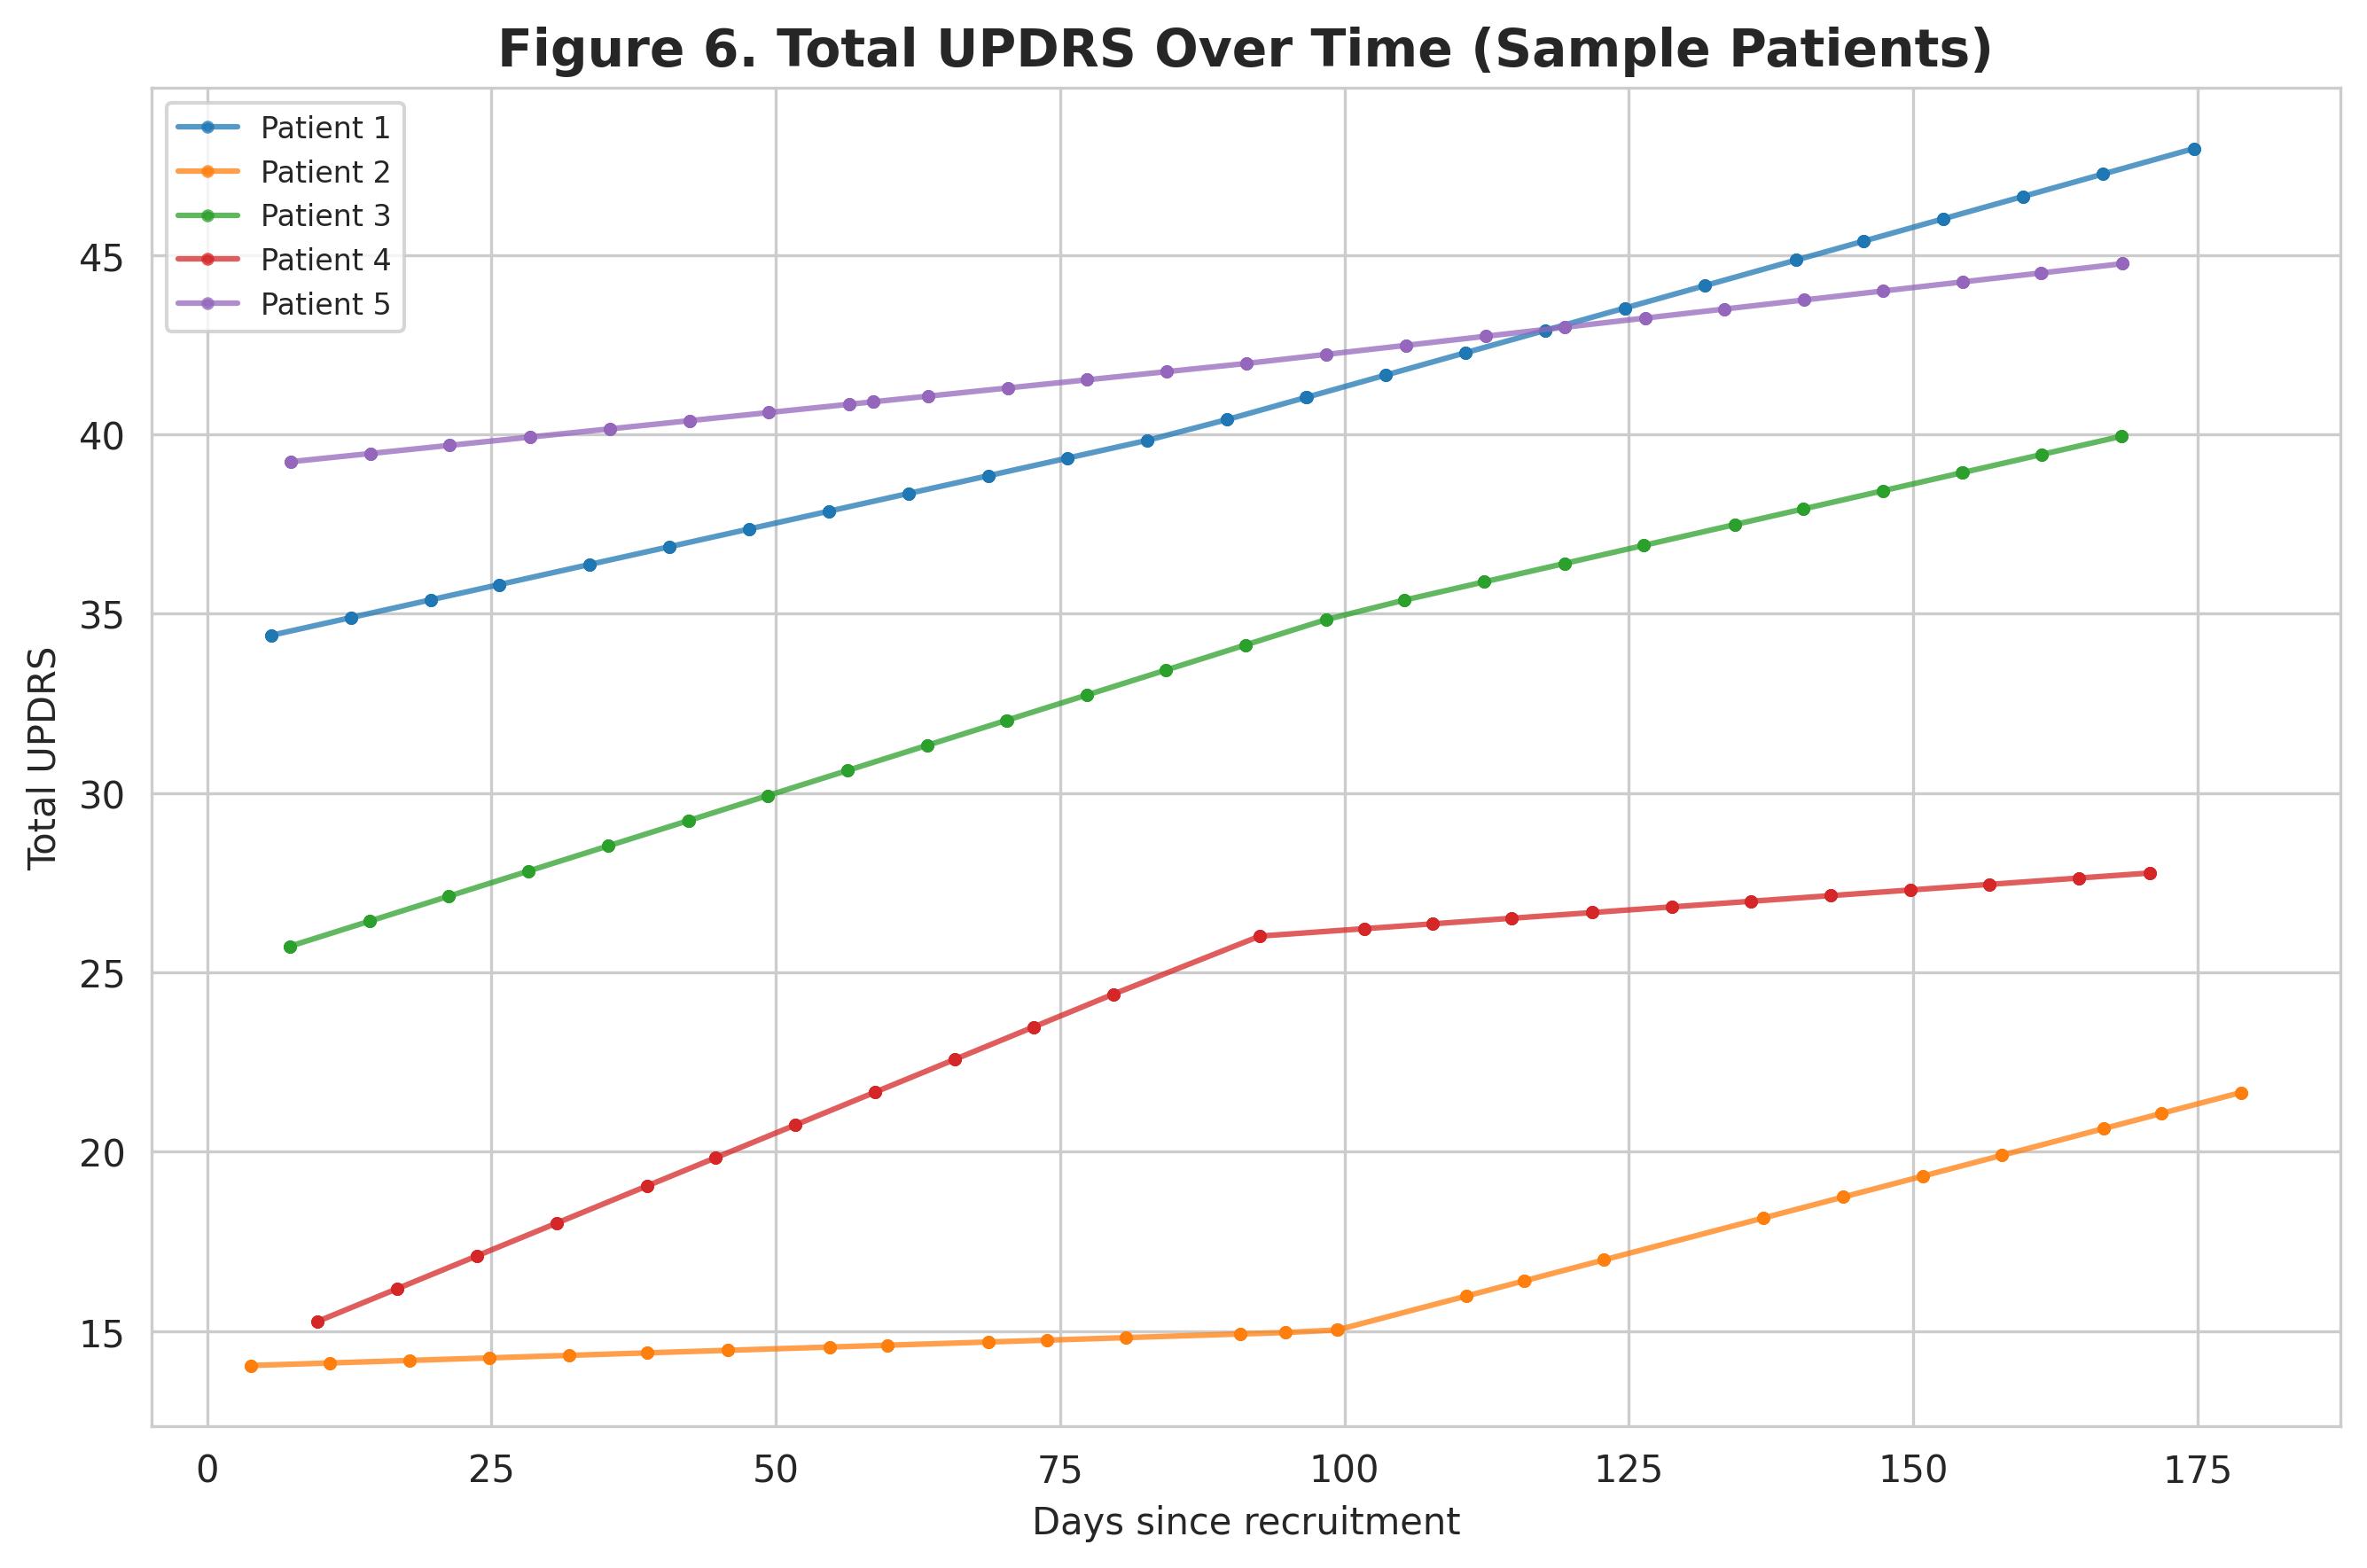

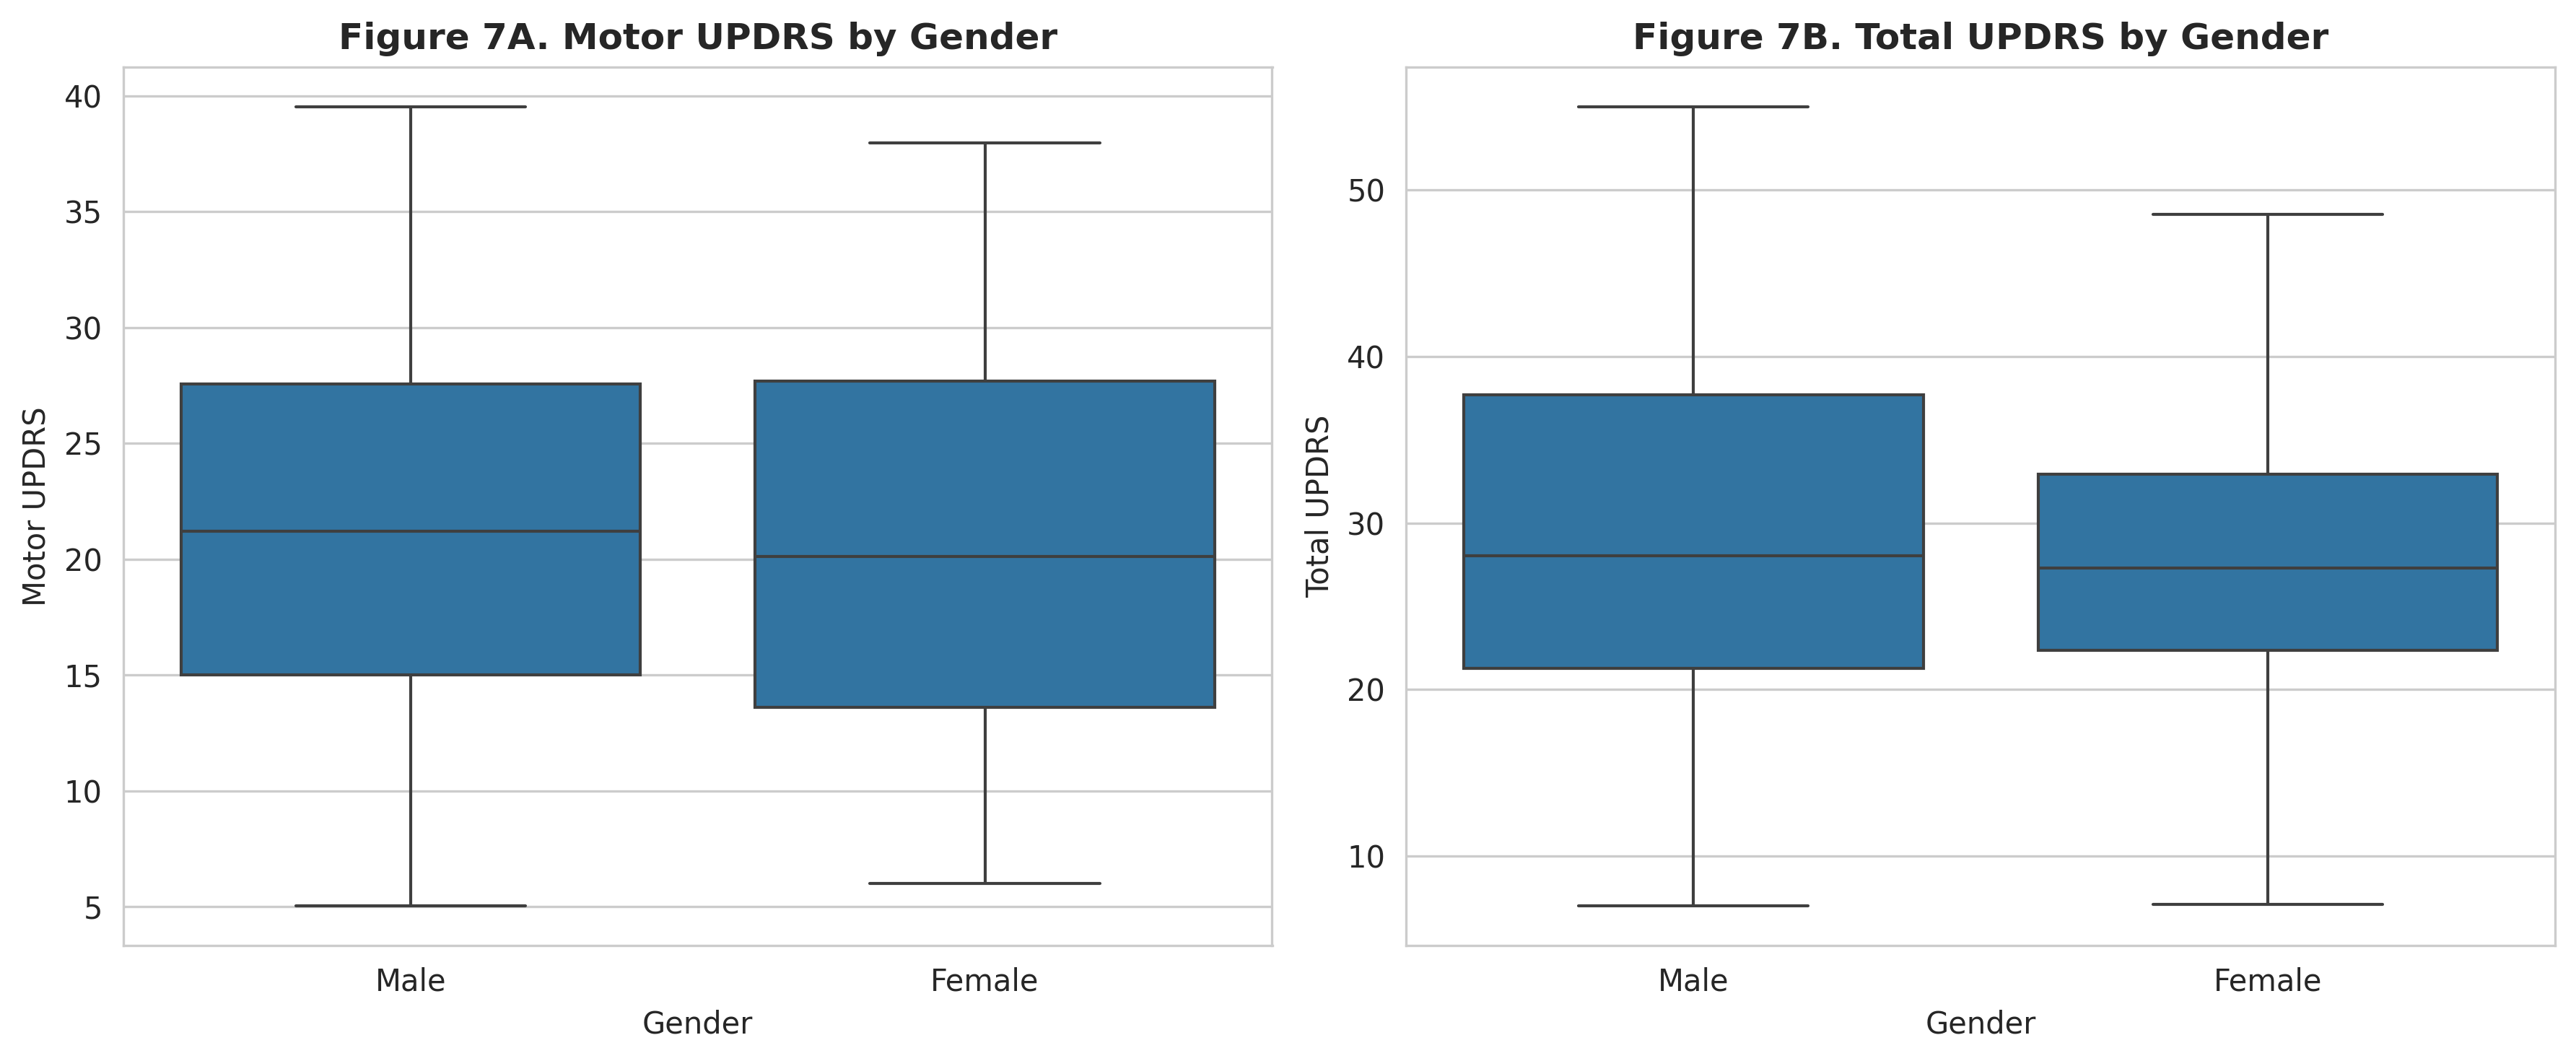

All figures saved successfully in: https://github.com/Sulu421/BIFX-546_Project-Parkinson-s_Telemonitoring/tree/fa60e6784b1b5c061618090c69899151a1a74851/Results


In [11]:
# ============================
# DRIVE / RESULTS PATH BLOCK
# ============================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# OPTION 1: If running inside your repo locally, keep this:

results_path = "https://github.com/Sulu421/BIFX-546_Project-Parkinson-s_Telemonitoring/tree/fa60e6784b1b5c061618090c69899151a1a74851/Results"

# OPTION 2: If running in Google Colab with Google Drive mounted, use this instead:

# from google.colab import drive
# drive.mount('/content/drive')
# results_path = '/content/drive/MyDrive/BIFX-546_Project_Parkinsons_Telemonitoring/Results'

# Create the Results folder if it does not already exist
os.makedirs(results_path, exist_ok=True)

# ============================
# VISUALIZATION SETTINGS
# ============================

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["figure.dpi"] = 300

# Gender labels
df["Gender"] = df["sex"].map({0: "Male", 1: "Female"})

voice_features = [
    "Jitter(%)", "Jitter(Abs)", "Jitter:RAP", "Jitter:PPQ5", "Jitter:DDP",
    "Shimmer", "Shimmer(dB)", "Shimmer:APQ3", "Shimmer:APQ5", "Shimmer:APQ11",
    "Shimmer:DDA", "NHR", "HNR", "RPDE", "DFA", "PPE"
]

# ============================
# FIGURE 1: MOTOR UPDRS VS AGE
# ============================

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="age", y="motor_UPDRS", alpha=0.35, s=30, color="steelblue")
sns.regplot(data=df, x="age", y="motor_UPDRS", scatter=False, color="darkred",
            line_kws={"linewidth": 2})
plt.title("Figure 1. motor_UPDRS vs Age", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("motor_UPDRS")
plt.tight_layout()
plt.savefig(os.path.join(results_path, "figure1_motor_age.png"), bbox_inches="tight")
plt.show()

# ============================
# FIGURE 2: TOTAL UPDRS VS AGE
# ============================

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="age", y="total_UPDRS", alpha=0.35, s=30, color="seagreen")
sns.regplot(data=df, x="age", y="total_UPDRS", scatter=False, color="darkorange",
            line_kws={"linewidth": 2})
plt.title("Figure 2. total_UPDRS vs Age", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Total UPDRS")
plt.tight_layout()
plt.savefig(os.path.join(results_path, "figure2_total_age.png"), bbox_inches="tight")
plt.show()

# ============================
# FIGURE 3A AND 3B: DISTRIBUTIONS
# ============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df["motor_UPDRS"], bins=30, kde=True, color="steelblue", ax=axes[0])
axes[0].axvline(df["motor_UPDRS"].mean(), color="darkred", linestyle="--", linewidth=2)
axes[0].set_title("Figure 3A. Motor UPDRS Distribution", fontweight="bold")
axes[0].set_xlabel("Motor UPDRS")
axes[0].set_ylabel("Count")

sns.histplot(df["total_UPDRS"], bins=30, kde=True, color="seagreen", ax=axes[1])
axes[1].axvline(df["total_UPDRS"].mean(), color="darkorange", linestyle="--", linewidth=2)
axes[1].set_title("Figure 3B. Total UPDRS Distribution", fontweight="bold")
axes[1].set_xlabel("Total UPDRS")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(os.path.join(results_path, "figure3_distributions.png"), bbox_inches="tight")
plt.show()

# ============================
# FIGURE 4: CORRELATION HEATMAP
# ============================

heatmap_cols = voice_features + ["motor_UPDRS", "total_UPDRS"]

plt.figure(figsize=(12, 10))
corr = df[heatmap_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Figure 4. Voice Features and UPDRS Correlation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(results_path, "figure4_heatmap.png"), bbox_inches="tight")
plt.show()

# ============================
# FIGURE 5: MOTOR UPDRS OVER TIME
# ============================

sample_patients = df["subject#"].drop_duplicates().head(5).tolist()

plt.figure(figsize=(9, 6))
for patient in sample_patients:
    patient_data = df[df["subject#"] == patient].sort_values("test_time")
    plt.plot(patient_data["test_time"], patient_data["motor_UPDRS"],
             marker="o", markersize=2.5, alpha=0.75, label=f"Patient {patient}")

plt.title("Figure 5. Motor UPDRS Over Time (Sample Patients)", fontsize=14, fontweight="bold")
plt.xlabel("Days since recruitment")
plt.ylabel("Motor UPDRS")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(results_path, "figure5_motor_time.png"), bbox_inches="tight")
plt.show()

# ============================
# FIGURE 6: TOTAL UPDRS OVER TIME
# ============================

plt.figure(figsize=(9, 6))
for patient in sample_patients:
    patient_data = df[df["subject#"] == patient].sort_values("test_time")
    plt.plot(patient_data["test_time"], patient_data["total_UPDRS"],
             marker="o", markersize=2.5, alpha=0.75, label=f"Patient {patient}")

plt.title("Figure 6. Total UPDRS Over Time (Sample Patients)", fontsize=14, fontweight="bold")
plt.xlabel("Days since recruitment")
plt.ylabel("Total UPDRS")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(results_path, "figure6_total_time.png"), bbox_inches="tight")
plt.show()

# ============================
# FIGURE 7A AND 7B: GENDER COMPARISON
# ============================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="Gender", y="motor_UPDRS", ax=axes[0])
axes[0].set_title("Figure 7A. Motor UPDRS by Gender", fontweight="bold")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Motor UPDRS")

sns.boxplot(data=df, x="Gender", y="total_UPDRS", ax=axes[1])
axes[1].set_title("Figure 7B. Total UPDRS by Gender", fontweight="bold")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Total UPDRS")

plt.tight_layout()
plt.savefig(os.path.join(results_path, "figure7_gender_boxplots.png"), bbox_inches="tight")
plt.show()

print(f"All figures saved successfully in: {results_path}")

The exploratory analysis was expanded to visualize motor_UPDRS and total_UPDRS separately rather than combining them into a single figure.

1) The age-based scatterplots suggest only a modest positive association
between age and both clinical targets, with substantial variability across patients.
2) The distribution plots show that both outcomes are continuous and somewhat skewed, which is relevant when selecting and evaluating regression models.
3) The heatmap including all voice features highlights correlations between biomedical speech measures and the UPDRS outcomes while also revealing redundancy among related features.
4) The longitudinal patient plots demonstrate subject-specific trajectories over time and support the use of grouped splitting strategies to avoid patient-level data leakage.
5) Finally, gender-based boxplots provide demographic context, although overlap between groups suggests that sex alone is not likely to explain most variation in disease severity.
